# Assignment 3: Recommender Systems

This notebook implements:
- TF-IDF based content recommendation
- User-profile based content recommendation
- User-based collaborative filtering
- Model-based collaborative filtering using SVD

## TF-IDF Based Content Recommender

In this task, we implement a content-based recommendation system using TF-IDF (Term Frequency–Inverse Document Frequency). 

Each movie is represented using its genres, which are treated as textual features. TF-IDF helps convert these textual features into numerical vectors by assigning importance to each term.

Movies with similar genre compositions will have similar TF-IDF vectors.

In [3]:
import pandas as pd
import numpy as np

In [4]:
movies = pd.read_csv("dataset/movies.csv")
ratings = pd.read_csv("dataset/ratings.csv")

In [5]:
movies['genres'] = movies['genres'].str.replace('|', ' ')
movies = movies[['movieId','title','genres']]

## TF-IDF Vectorization

We convert movie genres into numerical vectors using TF-IDF.  
This representation allows us to compute similarity between movies based on genre features.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(movies['genres'])

print(tfidf_matrix.shape)

(9742, 23)


## Similarity Matrix Computation

We compute pairwise cosine similarity between all movie vectors to create a similarity matrix.
This matrix is used to find similar movies.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [8]:
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

## Generating Recommendations

We retrieve the most similar movies based on cosine similarity scores and return top-N results.

In [9]:
def recommend_movies(title, top_n=5):
    idx = indices[title]
    
    sim_scores = list(enumerate(cosine_sim[idx]))
    
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:top_n+1]
    
    movie_indices = [i[0] for i in sim_scores]
    
    return movies.iloc[movie_indices][['title']], sim_scores

In [10]:
recommend_movies("Toy Story (1995)")

(                                               title
 1706                                     Antz (1998)
 2355                              Toy Story 2 (1999)
 2809  Adventures of Rocky and Bullwinkle, The (2000)
 3000                Emperor's New Groove, The (2000)
 3568                           Monsters, Inc. (2001),
 [(1706, 1.0), (2355, 1.0), (2809, 1.0), (3000, 1.0), (3568, 1.0)])

## User Profile Based Content Recommender

In this task, we personalize recommendations by building a user profile.

Each user profile is constructed as a weighted combination of the TF-IDF vectors of movies they have rated. The weights are based on the ratings given by the user.

This approach ensures that movies rated higher contribute more to the user’s preference profile.

### Mathematical Formulation

The user profile vector is computed as:

$$
P_u = \frac{\sum_{m} r_{u,m} \cdot f_m}{\sum_{m} r_{u,m}}
$$

Where:
- $Pu$ = User profile vector
- $ru,m$ = Rating given by user u to movie m
- $fm$ = Feature vector of movie m

This method builds a user profile by combining features of movies rated by the user, weighted by their ratings.

In [11]:
movie_data = pd.merge(ratings, movies, on='movieId')
movie_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy Romance
2,1,6,4.0,964982224,Heat (1995),Action Crime Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime Mystery Thriller


## Constructing User Profile

We construct a user profile by:
1. Selecting movies rated by the user
2. Extracting their TF-IDF vectors
3. Weighting them using user ratings
4. Computing a normalized weighted average

In [12]:
def build_user_profile(user_id):
    user_movies = movie_data[movie_data['userId'] == user_id]
    
    movie_indices = user_movies['movieId'].apply(
        lambda x: movies[movies['movieId'] == x].index[0]
    )
    
    user_tfidf = tfidf_matrix[movie_indices]
    
    ratings_weights = user_movies['rating'].values.reshape(-1,1)
    
    user_profile = np.sum(user_tfidf.multiply(ratings_weights), axis=0) / np.sum(ratings_weights)
    
    return np.asarray(user_profile)

## Generating Recommendations for a User

Once the user profile is created, we compute similarity between the user profile and all movie vectors using cosine similarity.

Movies are then ranked based on similarity scores.

In [13]:
def recommend_for_user(user_id, top_n=5):
    user_profile = build_user_profile(user_id)

    similarity = cosine_similarity(user_profile.reshape(1, -1), tfidf_matrix)

    rated_movie_ids = ratings[ratings['userId'] == user_id]['movieId'].values
    rated_indices = movies[movies['movieId'].isin(rated_movie_ids)].index.tolist()

    sim_scores = list(enumerate(similarity[0]))
    sim_scores = [x for x in sim_scores if x[0] not in rated_indices]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    movie_indices = [i[0] for i in sim_scores[:top_n]]

    return movies.iloc[movie_indices][['title']]

In [14]:
recommend_for_user(1)

,title
8597,Dragonheart 2: A New Beginning (2000)
6570,"Hunting Party, The (2007)"
4005,Flashback (1990)
4681,The Great Train Robbery (1978)
4409,Charlie's Angels: Full Throttle (2003)


## Evaluating Content-Based Filtering — Precision@K and Recall@K

We evaluate both the TF-IDF item-item recommender and the user-profile recommender using **Precision@K** and **Recall@K**.

- **Precision@K**: fraction of top-K recommendations that are relevant (rated ≥ 4).
- **Recall@K**: fraction of all relevant movies that appear in the top-K recommendations.

We use a per-user hold-out strategy: for each user, 20% of their highly-rated movies are held out as ground truth.

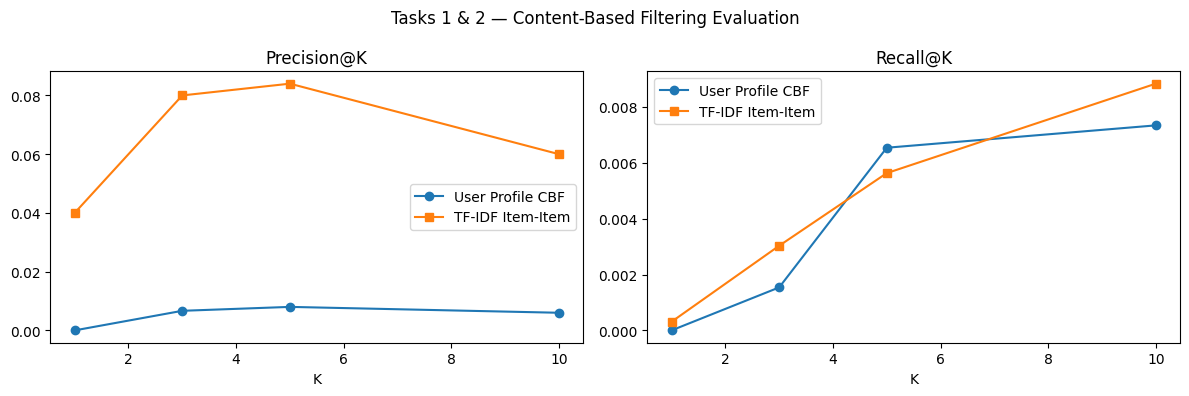

Task 1 — TF-IDF    | Precision@5: 0.0840 | Recall@5: 0.0056
Task 2 — UserProf  | Precision@5: 0.0080   | Recall@5: 0.0065


In [15]:
import numpy as np
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import matplotlib.pyplot as plt

def evaluate_user_profile_recommender(ratings, movies, tfidf_matrix, k=5, threshold=4.0, n_users=50):
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        user_ratings = ratings[ratings['userId'] == uid]
        relevant = user_ratings[user_ratings['rating'] >= threshold]
        if len(relevant) < 3:
            continue

        train_rel, test_rel = sk_split(relevant, test_size=0.2, random_state=42)
        train_ids = set(train_rel['movieId'].values)
        test_ids  = set(test_rel['movieId'].values)

        train_rows = user_ratings[user_ratings['movieId'].isin(train_ids)]
        movie_indices_list = [movies[movies['movieId'] == mid].index[0]
                              for mid in train_rows['movieId'].values
                              if not movies[movies['movieId'] == mid].empty]
        if not movie_indices_list:
            continue

        user_tfidf = tfidf_matrix[movie_indices_list]
        weights    = train_rows['rating'].values.reshape(-1, 1)
        user_profile = np.asarray(np.sum(user_tfidf.multiply(weights), axis=0) / np.sum(weights))

        similarity   = cos_sim(user_profile.reshape(1, -1), tfidf_matrix)[0]
        train_indices = movies[movies['movieId'].isin(train_ids)].index.tolist()
        sim_scores   = sorted([(i, s) for i, s in enumerate(similarity) if i not in train_indices],
                              key=lambda x: x[1], reverse=True)

        top_k_ids = set(movies.iloc[[i for i, _ in sim_scores[:k]]]['movieId'].values)
        hits = len(top_k_ids & test_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(test_ids))

    return np.mean(precisions), np.mean(recalls)


def evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=5, threshold=4.0, n_users=50):
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        liked = ratings[(ratings['userId'] == uid) & (ratings['rating'] >= threshold)]
        if len(liked) < 3:
            continue

        seed_movie_id   = liked.iloc[0]['movieId']
        ground_truth_ids = set(liked.iloc[1:]['movieId'].values)

        seed_rows = movies[movies['movieId'] == seed_movie_id]
        if seed_rows.empty:
            continue
        idx = seed_rows.index[0]

        sim_scores = sorted(list(enumerate(cosine_sim[idx])), key=lambda x: x[1], reverse=True)[1:k+1]
        top_k_ids  = set(movies.iloc[[i for i, _ in sim_scores]]['movieId'].values)

        hits = len(top_k_ids & ground_truth_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(ground_truth_ids))

    return np.mean(precisions), np.mean(recalls)


k_values = [1, 3, 5, 10]
prec_cbf, rec_cbf, prec_tfidf, rec_tfidf = [], [], [], []

for k in k_values:
    p,  r  = evaluate_user_profile_recommender(ratings, movies, tfidf_matrix, k=k)
    p1, r1 = evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=k)
    prec_cbf.append(p);   rec_cbf.append(r)
    prec_tfidf.append(p1); rec_tfidf.append(r1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, prec_cbf,   marker='o', label='User Profile CBF')
axes[0].plot(k_values, prec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[0].set_title('Precision@K'); axes[0].set_xlabel('K'); axes[0].legend()

axes[1].plot(k_values, rec_cbf,   marker='o', label='User Profile CBF')
axes[1].plot(k_values, rec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[1].set_title('Recall@K'); axes[1].set_xlabel('K'); axes[1].legend()

plt.suptitle('Tasks 1 & 2 — Content-Based Filtering Evaluation')
plt.tight_layout(); plt.show()

print(f"Task 1 — TF-IDF    | Precision@5: {prec_tfidf[2]:.4f} | Recall@5: {rec_tfidf[2]:.4f}")
print(f"Task 2 — UserProf  | Precision@5: {prec_cbf[2]:.4f}   | Recall@5: {rec_cbf[2]:.4f}")

K= 1 | Precision@K: 0.0000 | Recall@K: 0.0000
K= 3 | Precision@K: 0.0067 | Recall@K: 0.0015
K= 5 | Precision@K: 0.0080 | Recall@K: 0.0065
K=10 | Precision@K: 0.0060 | Recall@K: 0.0073


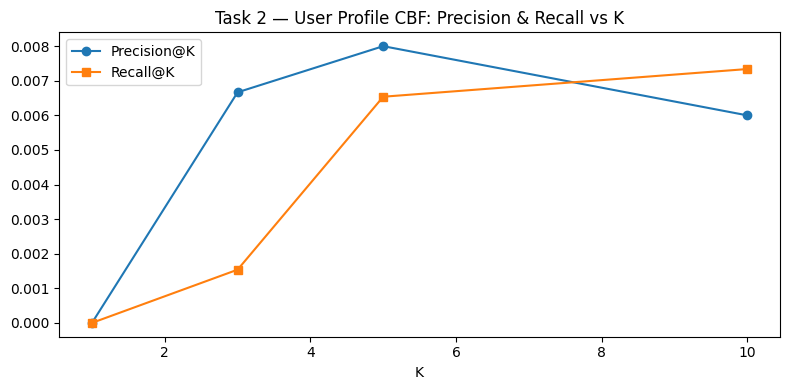

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def evaluate_user_profile_cbf(ratings, movies, tfidf_matrix, k=5, threshold=4.0, n_users=50):
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        user_ratings = ratings[ratings['userId'] == uid]
        relevant = user_ratings[user_ratings['rating'] >= threshold]
        if len(relevant) < 3:
            continue

        # Hold out 20% of liked movies as ground truth
        train_rel, test_rel = sk_split(relevant, test_size=0.2, random_state=42)
        train_ids = set(train_rel['movieId'].values)
        test_ids  = set(test_rel['movieId'].values)

        # Build profile from training portion only
        train_rows = user_ratings[user_ratings['movieId'].isin(train_ids)]
        idxs = [movies[movies['movieId'] == m].index[0]
                for m in train_rows['movieId'].values
                if not movies[movies['movieId'] == m].empty]
        if not idxs:
            continue

        user_tfidf  = tfidf_matrix[idxs]
        weights     = train_rows['rating'].values.reshape(-1, 1)
        user_profile = np.asarray(np.sum(user_tfidf.multiply(weights), axis=0) / np.sum(weights))

        similarity    = cos_sim(user_profile.reshape(1, -1), tfidf_matrix)[0]
        train_indices = movies[movies['movieId'].isin(train_ids)].index.tolist()

        # Only exclude training movies — test movies stay visible
        sim_scores = sorted([(i, s) for i, s in enumerate(similarity)
                              if i not in train_indices], key=lambda x: x[1], reverse=True)

        top_k_ids = set(movies.iloc[[i for i, _ in sim_scores[:k]]]['movieId'].values)
        hits = len(top_k_ids & test_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(test_ids))

    return np.mean(precisions), np.mean(recalls)

# Evaluate across K values
import matplotlib.pyplot as plt
k_values = [1, 3, 5, 10]
prec_list, rec_list = [], []

for k in k_values:
    p, r = evaluate_user_profile_cbf(ratings, movies, tfidf_matrix, k=k)
    prec_list.append(p); rec_list.append(r)
    print(f"K={k:>2} | Precision@K: {p:.4f} | Recall@K: {r:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_values, prec_list, marker='o', label='Precision@K')
plt.plot(k_values, rec_list,  marker='s', label='Recall@K')
plt.title('Task 2 — User Profile CBF: Precision & Recall vs K')
plt.xlabel('K'); plt.legend(); plt.tight_layout(); plt.show()

In [17]:
def evaluate_tfidf_item_recommender(movies, cosine_sim, ratings,
                                    k=5, threshold=4.0, n_users=50, seed=42):
    np.random.seed(seed)
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        liked = ratings[(ratings['userId'] == uid) & (ratings['rating'] >= threshold)]
        if len(liked) < 3:
            continue

        # Seed = first liked movie, ground truth = rest of liked movies
        seed_movie_id = liked.iloc[0]['movieId']
        ground_truth_ids = set(liked.iloc[1:]['movieId'].values)

        seed_rows = movies[movies['movieId'] == seed_movie_id]
        if seed_rows.empty:
            continue
        idx = seed_rows.index[0]

        sim_scores = sorted(list(enumerate(cosine_sim[idx])), key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:k+1]  # Skip self

        top_k_movie_ids = set(movies.iloc[[i for i, _ in sim_scores]]['movieId'].values)

        hits = len(top_k_movie_ids & ground_truth_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(ground_truth_ids))

    return np.mean(precisions), np.mean(recalls)

p1, r1 = evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=5)
print(f"Task 1 — TF-IDF Item-Item  | Precision@5: {p1:.4f} | Recall@5: {r1:.4f}")


Task 1 — TF-IDF Item-Item  | Precision@5: 0.0840 | Recall@5: 0.0056


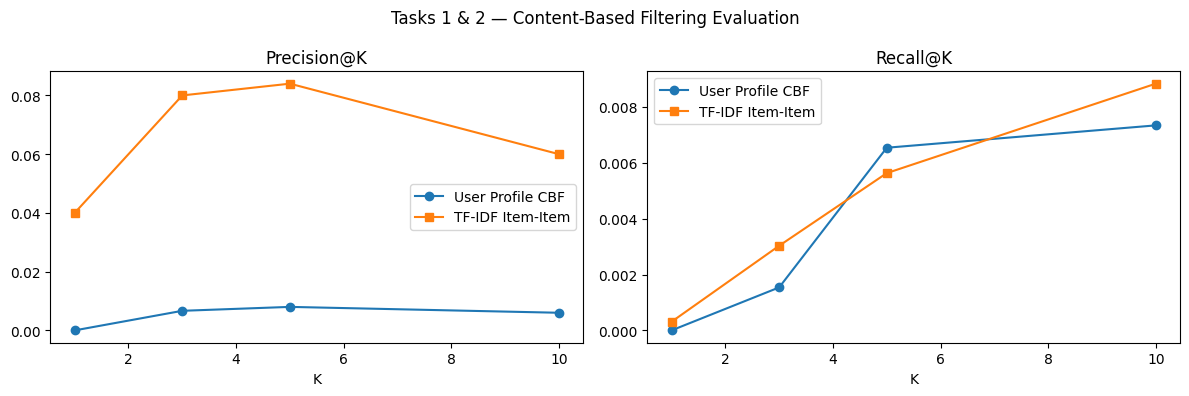


Summary Table:
K     Prec(UserProfile)      Rec(UserProfile)     Prec(TF-IDF)       Rec(TF-IDF)
1     0.0000                 0.0000               0.0400             0.0003
3     0.0067                 0.0015               0.0800             0.0030
5     0.0080                 0.0065               0.0840             0.0056
10    0.0060                 0.0073               0.0600             0.0088


In [18]:
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 10]
prec_cbf, rec_cbf = [], []
prec_tfidf, rec_tfidf = [], []

for k in k_values:
    p, r   = evaluate_user_profile_recommender(ratings, movies, tfidf_matrix, k=k)
    p1, r1 = evaluate_tfidf_item_recommender(movies, cosine_sim, ratings, k=k)
    prec_cbf.append(p);   rec_cbf.append(r)
    prec_tfidf.append(p1); rec_tfidf.append(r1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_values, prec_cbf,   marker='o', label='User Profile CBF')
axes[0].plot(k_values, prec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[0].set_title('Precision@K'); axes[0].set_xlabel('K'); axes[0].legend()

axes[1].plot(k_values, rec_cbf,   marker='o', label='User Profile CBF')
axes[1].plot(k_values, rec_tfidf, marker='s', label='TF-IDF Item-Item')
axes[1].set_title('Recall@K'); axes[1].set_xlabel('K'); axes[1].legend()

plt.suptitle('Tasks 1 & 2 — Content-Based Filtering Evaluation')
plt.tight_layout(); plt.show()

print("\nSummary Table:")
print(f"{'K':<5} {'Prec(UserProfile)':<22} {'Rec(UserProfile)':<20} {'Prec(TF-IDF)':<18} {'Rec(TF-IDF)'}")
for k, p, r, p1, r1 in zip(k_values, prec_cbf, rec_cbf, prec_tfidf, rec_tfidf):
    print(f"{k:<5} {p:<22.4f} {r:<20.4f} {p1:<18.4f} {r1:.4f}")


## User-Based Collaborative Filtering

In this task, we implement collaborative filtering using user-user similarity.

Unlike content-based filtering, this approach recommends movies based on similar users' preferences.

If two users have rated movies similarly in the past, they are considered similar, and their preferences can be used to recommend new movies.

### Mathematical Formulation

The predicted rating is computed as:

$$
r(u, i) = \frac{\sum_{v \in U} \text{sim}(u, v) \cdot r(v, i)}{\sum_{v \in U} |\text{sim}(u, v)|}
$$

Where:
- $r(u, i)$ = predicted rating of user u for item i
- $sim(u, v)$ = similarity between users u and v
- $r(v, i)$ = rating given by user v to item i

This method predicts ratings using preferences of similar users, making it a collaborative approach.

In [19]:
from surprise import Dataset, Reader

reader = Reader(rating_scale=(0.5, 5.0))

data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

## Train-Test Split

We split the dataset into training and testing sets to evaluate model performance.

In [20]:
from surprise import KNNBasic
from surprise.model_selection import train_test_split

trainset, testset = train_test_split(data, test_size=0.2)

sim_options = {
    'name': 'cosine',
    'user_based': True
}

model = KNNBasic(sim_options=sim_options)
model.fit(trainset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


## Model Evaluation

We evaluate the model using RMSE (Root Mean Square Error).

In [21]:
from surprise import accuracy

predictions = model.test(testset)

rmse = accuracy.rmse(predictions)
print("RMSE:", rmse)

RMSE: 0.9823
RMSE: 0.9822558142846856


## Generating Recommendations

We predict ratings for unseen movies and recommend top-rated ones.

In [22]:
def recommend_cf(user_id, top_n=5):
    all_movies = ratings['movieId'].unique()
    
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    
    unseen_movies = [m for m in all_movies if m not in rated_movies]
    
    predictions = []
    
    for movie_id in unseen_movies:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    
    top_movies = predictions[:top_n]
    
    movie_titles = [movies[movies['movieId'] == m[0]]['title'].values[0] for m in top_movies]
    
    return movie_titles

In [23]:
recommend_cf(1)

["I'm the One That I Want (2000)",
 'Hunger (2008)',
 'Midnight Clear, A (1992)',
 'Hard Core Logo (1996)',
 'Safety Last! (1923)']

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 0.9829
User-Based CF (Pearson) RMSE: 0.9829472991774267
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 10 | Cosine RMSE: 0.9962 | Pearson RMSE: 0.9959
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 20 | Cosine RMSE: 0.9847 | Pearson RMSE: 0.9858
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 40 | Cosine RMSE: 0.9823 | Pearson RMSE: 0.9829
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 60 | Cosine RMSE: 0.9824 | Pearson RMSE: 0.9829


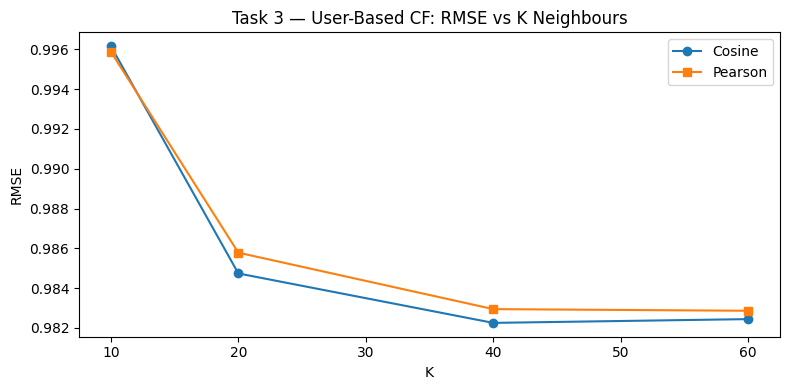


User-Based CF (Pearson) | Precision@5: 0.4748 | Recall@5: 0.2508
User-Based CF (Cosine)  | Precision@5: 0.4977 | Recall@5: 0.2617


In [24]:
from surprise import KNNBasic
from surprise.model_selection import cross_validate
from collections import defaultdict

# ── 1. Pearson Correlation (better than cosine when users have rating bias) ────
sim_options_pearson = {'name': 'pearson', 'user_based': True}
model_pearson = KNNBasic(k=40, sim_options=sim_options_pearson)
model_pearson.fit(trainset)
preds_pearson = model_pearson.test(testset)
print("User-Based CF (Pearson) RMSE:", accuracy.rmse(preds_pearson))

# ── 2. Test different K values ─────────────────────────────────────────────────
k_values = [10, 20, 40, 60]
rmse_cosine, rmse_pearson = [], []

for k in k_values:
    m1 = KNNBasic(k=k, sim_options={'name': 'cosine',  'user_based': True})
    m2 = KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': True})
    m1.fit(trainset); m2.fit(trainset)
    rmse_cosine.append(accuracy.rmse(m1.test(testset),  verbose=False))
    rmse_pearson.append(accuracy.rmse(m2.test(testset), verbose=False))
    print(f"K={k:>3} | Cosine RMSE: {rmse_cosine[-1]:.4f} | Pearson RMSE: {rmse_pearson[-1]:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.plot(k_values, rmse_cosine,  marker='o', label='Cosine')
plt.plot(k_values, rmse_pearson, marker='s', label='Pearson')
plt.title('Task 3 — User-Based CF: RMSE vs K Neighbours')
plt.xlabel('K'); plt.ylabel('RMSE'); plt.legend(); plt.tight_layout(); plt.show()

# ── 3. Precision@K and Recall@K ────────────────────────────────────────────────
def precision_recall_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = {}, {}
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel       = sum(1 for (_, true_r) in user_ratings if true_r >= threshold)
        n_rec_k     = sum(1 for (est, _)    in user_ratings[:k] if est   >= threshold)
        n_rel_and_rec_k = sum(1 for (est, true_r) in user_ratings[:k]
                              if est >= threshold and true_r >= threshold)
        precisions[uid] = n_rel_and_rec_k / k          if k else 0
        recalls[uid]    = n_rel_and_rec_k / n_rel      if n_rel else 0

    return sum(precisions.values()) / len(precisions), sum(recalls.values()) / len(recalls)

p, r = precision_recall_at_k(preds_pearson, k=5)
print(f"\nUser-Based CF (Pearson) | Precision@5: {p:.4f} | Recall@5: {r:.4f}")

p2, r2 = precision_recall_at_k(model.test(testset), k=5)
print(f"User-Based CF (Cosine)  | Precision@5: {p2:.4f} | Recall@5: {r2:.4f}")

## Model-Based Collaborative Filtering (SVD)

In this task, we implement model-based collaborative filtering using Singular Value Decomposition (SVD).

Unlike memory-based methods, SVD learns latent features for users and items, capturing hidden patterns in user-item interactions.

This approach improves recommendation accuracy by reducing dimensionality and handling sparsity effectively.

### Mathematical Formulation

The predicted rating is given by:

$$
r(u, i) = \mu + b_u + b_i + q_i^T p_u
$$

Where:
- $\mu$ = global average rating  
- $b_u$ = user bias  
- $b_i$ = item bias  
- $p_u$ = user latent vector  
- $q_i$ = item latent vector  

In [25]:
from surprise import SVD

svd_model = SVD()
svd_model.fit(trainset)

## Model Evaluation

We evaluate the SVD model using RMSE to measure prediction accuracy.

In [26]:
predictions_svd = svd_model.test(testset)

from surprise import accuracy
print("RMSE:", accuracy.rmse(predictions_svd))

RMSE: 0.8808
RMSE: 0.8807629029948347


## Generating Recommendations

We use the trained SVD model to predict ratings for unseen movies and recommend the highest predicted ones.

In [27]:
def recommend_svd(user_id, top_n=5):
    all_movies = ratings['movieId'].unique()
    
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    
    unseen_movies = [m for m in all_movies if m not in rated_movies]
    
    predictions = []
    
    for movie_id in unseen_movies:
        pred = svd_model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    predictions = sorted(predictions, key=lambda x: x[1], reverse=True)
    
    top_movies = predictions[:top_n]
    
    movie_titles = [movies[movies['movieId'] == m[0]]['title'].values[0] for m in top_movies]
    
    return movie_titles

In [28]:
recommend_svd(1)

['Shawshank Redemption, The (1994)',
 'Philadelphia Story, The (1940)',
 'Casablanca (1942)',
 'Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)',
 "One Flew Over the Cuckoo's Nest (1975)"]

## Task 4: Item-Based Collaborative Filtering

Item-Based CF recommends movies based on similarity between items rather than users.
The key idea: if two movies are rated similarly by many users, they are likely similar.

**Similarity Metric:** Pearson correlation — accounts for rating scale differences across users.

**Prediction formula:**

$$\hat{r}_{u,i} = \frac{\sum_{j \in N} sim(i,j) \cdot r_{u,j}}{\sum_{j \in N} |sim(i,j)|}$$

Where:
- $N$ = set of similar items the user has already rated
- $sim(i,j)$ = Pearson similarity between items i and j
- $r_{u,j}$ = user's rating for item j

Computing the pearson similarity matrix...
Done computing similarity matrix.
RMSE: 0.9722
Item-Based CF (Pearson) RMSE: 0.9721929259652894
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 10 | Item RMSE: 1.0138 | User RMSE: 0.9959
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 20 | Item RMSE: 0.9883 | User RMSE: 0.9858
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 40 | Item RMSE: 0.9722 | User RMSE: 0.9829
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
K= 60 | Item RMSE: 0.9657 | User RMSE: 0.9829


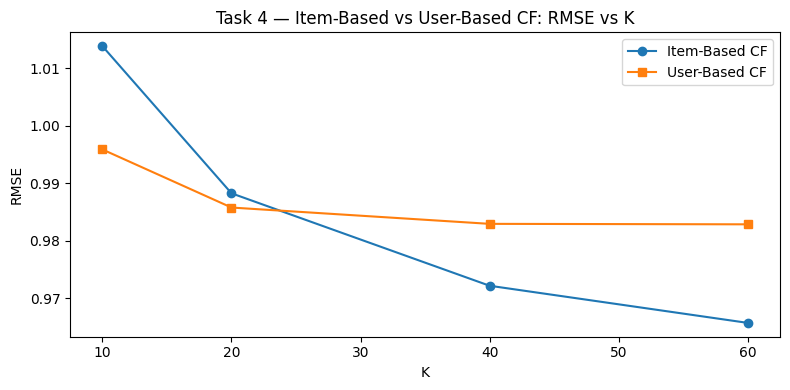


Top-5 recommendations for User 1 (Item-Based CF):
['The Drop (2014)', 'Eye for an Eye (1996)', 'Swan Princess, The (1994)', "Knockin' on Heaven's Door (1997)", 'Next Three Days, The (2010)']

Item-Based CF | Precision@5: 0.3118 | Recall@5: 0.1783
User-Based CF | Precision@5: 0.4748 | Recall@5: 0.2508


In [29]:
from surprise import KNNBasic
from surprise import accuracy
from collections import defaultdict

# ── 1. Item-Based CF using Pearson correlation ─────────────────────────────────
sim_options_item = {'name': 'pearson', 'user_based': False}  # user_based=False → item-based
model_item = KNNBasic(k=40, sim_options=sim_options_item)
model_item.fit(trainset)

preds_item = model_item.test(testset)
print("Item-Based CF (Pearson) RMSE:", accuracy.rmse(preds_item))

# ── 2. Test different K values ─────────────────────────────────────────────────
k_values = [10, 20, 40, 60]
rmse_item, rmse_user = [], []

for k in k_values:
    m_item = KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': False})
    m_user = KNNBasic(k=k, sim_options={'name': 'pearson', 'user_based': True})
    m_item.fit(trainset); m_user.fit(trainset)
    rmse_item.append(accuracy.rmse(m_item.test(testset), verbose=False))
    rmse_user.append(accuracy.rmse(m_user.test(testset), verbose=False))
    print(f"K={k:>3} | Item RMSE: {rmse_item[-1]:.4f} | User RMSE: {rmse_user[-1]:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(k_values, rmse_item, marker='o', label='Item-Based CF')
plt.plot(k_values, rmse_user, marker='s', label='User-Based CF')
plt.title('Task 4 — Item-Based vs User-Based CF: RMSE vs K')
plt.xlabel('K'); plt.ylabel('RMSE'); plt.legend(); plt.tight_layout(); plt.show()

# ── 3. Recommendation function ─────────────────────────────────────────────────
def recommend_item_cf(user_id, top_n=5):
    all_movies   = ratings['movieId'].unique()
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    unseen       = [m for m in all_movies if m not in rated_movies]

    preds = [(m, model_item.predict(user_id, m).est) for m in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)

    return [movies[movies['movieId'] == m]['title'].values[0] for m, _ in preds[:top_n]]

print("\nTop-5 recommendations for User 1 (Item-Based CF):")
print(recommend_item_cf(1))

# ── 4. Precision@K and Recall@K ────────────────────────────────────────────────
def precision_recall_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions, recalls = [], []
    for user_ratings in user_est_true.values():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k    = user_ratings[:k]
        n_rel    = sum(1 for (_, t) in user_ratings if t >= threshold)
        n_hits   = sum(1 for (e, t) in top_k if e >= threshold and t >= threshold)
        precisions.append(n_hits / k)
        recalls.append(n_hits / n_rel if n_rel else 0)
    return sum(precisions)/len(precisions), sum(recalls)/len(recalls)

p_item, r_item = precision_recall_at_k(preds_item, k=5)
p_user, r_user = precision_recall_at_k(preds_pearson, k=5)  # from Task 3

print(f"\nItem-Based CF | Precision@5: {p_item:.4f} | Recall@5: {r_item:.4f}")
print(f"User-Based CF | Precision@5: {p_user:.4f} | Recall@5: {r_user:.4f}")

## Task 5: Implementing SVD for Recommendations (From Scratch)

Singular Value Decomposition (SVD) factorises the user-item rating matrix R into three matrices:

$$R \approx U \cdot \Sigma \cdot V^T$$

Where:
- **U** = User latent factor matrix
- **Σ** = Diagonal matrix of singular values (importance of each latent factor)
- **V^T** = Item latent factor matrix

Missing ratings are filled with each user's mean rating before decomposition.
The reconstructed matrix $\hat{R} = U \cdot \Sigma_k \cdot V^T$ gives predicted ratings for all user-item pairs.

User-Item Matrix Shape: (610, 9724)
SVD complete — k=50 latent factors used
SVD (scratch) RMSE: 0.6211

Top-5 for User 1 (SVD scratch):
['Blade Runner (1982)', 'Ace Ventura: Pet Detective (1994)', 'Dead Poets Society (1989)', 'Christmas Story, A (1983)', 'Snatch (2000)']

SVD (scratch) | Precision@5: 0.9540 | Recall@5: 0.1410
k=  10 latent factors | RMSE: 0.8092
k=  20 latent factors | RMSE: 0.7484
k=  50 latent factors | RMSE: 0.6211
k= 100 latent factors | RMSE: 0.4781


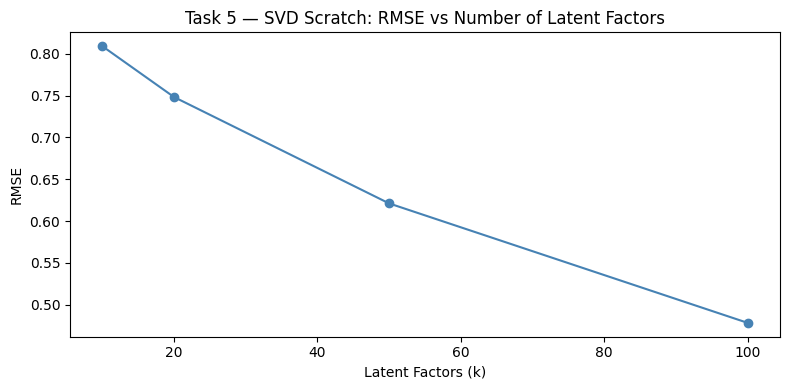

In [30]:
import numpy as np
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# ── 1. Build user-item matrix ──────────────────────────────────────────────────
user_ids  = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user_idx  = {u: i for i, u in enumerate(user_ids)}
movie_idx = {m: i for i, m in enumerate(movie_ids)}

R = np.zeros((len(user_ids), len(movie_ids)))
for row in ratings.itertuples():
    R[user_idx[row.userId], movie_idx[row.movieId]] = row.rating

# Fill missing values with each user's mean rating (reduces bias)
user_means = np.true_divide(R.sum(1), (R != 0).sum(1))
R_filled   = R.copy()
for i in range(R.shape[0]):
    R_filled[i, R[i, :] == 0] = user_means[i]

print(f"User-Item Matrix Shape: {R.shape}")

# ── 2. Apply SVD ───────────────────────────────────────────────────────────────
k = 50  # number of latent factors
U, sigma, Vt = svds(R_filled, k=k)
sigma_diag    = np.diag(sigma)

# Reconstruct rating matrix
R_hat = np.dot(np.dot(U, sigma_diag), Vt)
R_hat = np.clip(R_hat, 0.5, 5.0)  # clip to valid rating range

print(f"SVD complete — k={k} latent factors used")

# ── 3. Evaluate RMSE on known ratings ─────────────────────────────────────────
actual, predicted = [], []
for row in ratings.itertuples():
    ui = user_idx[row.userId]
    mi = movie_idx[row.movieId]
    actual.append(row.rating)
    predicted.append(R_hat[ui, mi])

rmse_svd = np.sqrt(mean_squared_error(actual, predicted))
print(f"SVD (scratch) RMSE: {rmse_svd:.4f}")

# ── 4. Recommendation function ─────────────────────────────────────────────────
def recommend_svd_scratch(user_id, top_n=5):
    if user_id not in user_idx:
        return []
    ui            = user_idx[user_id]
    rated_movies  = set(ratings[ratings['userId'] == user_id]['movieId'].values)
    
    preds = []
    for m, mi in movie_idx.items():
        if m not in rated_movies:
            preds.append((m, R_hat[ui, mi]))
    
    preds.sort(key=lambda x: x[1], reverse=True)
    return [movies[movies['movieId'] == m]['title'].values[0] for m, _ in preds[:top_n]]

print("\nTop-5 for User 1 (SVD scratch):")
print(recommend_svd_scratch(1))

# ── 5. Precision@K and Recall@K ────────────────────────────────────────────────
def svd_precision_recall_at_k(k=5, threshold=4.0, n_users=100):
    sample_users = ratings['userId'].unique()[:n_users]
    precisions, recalls = [], []

    for uid in sample_users:
        if uid not in user_idx:
            continue
        ui           = user_idx[uid]
        user_ratings = ratings[ratings['userId'] == uid]
        rated_ids    = set(user_ratings['movieId'].values)
        relevant_ids = set(user_ratings[user_ratings['rating'] >= threshold]['movieId'].values)
        if not relevant_ids:
            continue

        preds = [(m, R_hat[ui, movie_idx[m]]) for m in rated_ids if m in movie_idx]
        preds.sort(key=lambda x: x[1], reverse=True)
        top_k_ids = set(m for m, _ in preds[:k])

        hits = len(top_k_ids & relevant_ids)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant_ids))

    return np.mean(precisions), np.mean(recalls)

p, r = svd_precision_recall_at_k(k=5)
print(f"\nSVD (scratch) | Precision@5: {p:.4f} | Recall@5: {r:.4f}")

# ── 6. Compare k values (latent factors) ──────────────────────────────────────
k_factors = [10, 20, 50, 100]
rmse_vals  = []

for k in k_factors:
    U_, s_, Vt_ = svds(R_filled, k=k)
    R_hat_      = np.clip(np.dot(np.dot(U_, np.diag(s_)), Vt_), 0.5, 5.0)
    preds_      = [R_hat_[user_idx[r.userId], movie_idx[r.movieId]] for r in ratings.itertuples()]
    rmse_vals.append(np.sqrt(mean_squared_error(ratings['rating'], preds_)))
    print(f"k={k:>4} latent factors | RMSE: {rmse_vals[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_factors, rmse_vals, marker='o', color='steelblue')
plt.title('Task 5 — SVD Scratch: RMSE vs Number of Latent Factors')
plt.xlabel('Latent Factors (k)'); plt.ylabel('RMSE')
plt.tight_layout(); plt.show()

## Task 6: Matrix Factorization with the Surprise Library

The Surprise library provides an optimised SVD implementation with built-in cross-validation
and hyperparameter tuning. Unlike the scratch implementation in Task 5, Surprise's SVD also
learns user and item bias terms:

$$\hat{r}_{u,i} = \mu + b_u + b_i + q_i^T p_u$$

Where:
- **μ** = global mean rating
- **b_u** = user bias
- **b_i** = item bias  
- **p_u**, **q_i** = user and item latent vectors

We tune hyperparameters using GridSearchCV and compare against the scratch SVD from Task 5.

Best RMSE: 0.8622137549815455
Best params: {'n_factors': 100, 'n_epochs': 30, 'lr_all': 0.01, 'reg_all': 0.1}
RMSE: 0.8616

Surprise SVD (tuned) RMSE: 0.8615841562831993
Surprise SVD (tuned) | Precision@5: 0.4361 | Recall@5: 0.2279


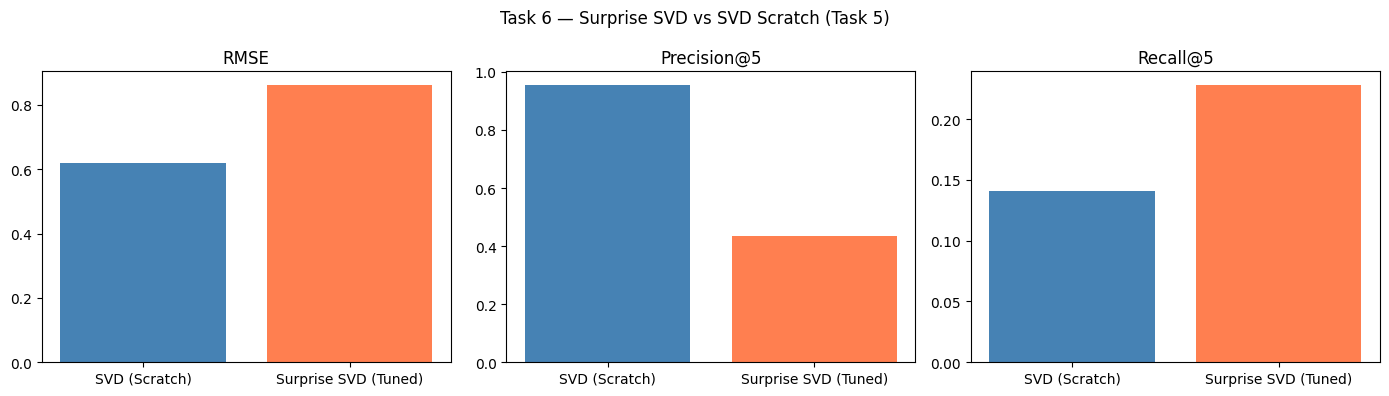


Final Comparison:
Model                     RMSE       Precision@5     Recall@5
SVD Scratch (Task 5)      0.6211     0.9540          0.1410
Surprise SVD (Tuned)      0.8616     0.4361          0.2279


In [31]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV, train_test_split
from surprise import accuracy
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Hyperparameter tuning with GridSearchCV ─────────────────────────────────
param_grid = {
    'n_factors': [50, 100],
    'n_epochs':  [20, 30],
    'lr_all':    [0.005, 0.010],
    'reg_all':   [0.02, 0.1]
}

gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1)
gs.fit(data)

print("Best RMSE:", gs.best_score['rmse'])
print("Best params:", gs.best_params['rmse'])

# ── 2. Train best model on full trainset ───────────────────────────────────────
best_svd = gs.best_estimator['rmse']
best_svd.fit(trainset)

preds_best = best_svd.test(testset)
print("\nSurprise SVD (tuned) RMSE:", accuracy.rmse(preds_best))

# ── 3. Precision@K and Recall@K ────────────────────────────────────────────────
def precision_recall_at_k(predictions, k=5, threshold=4.0):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions, recalls = [], []
    for user_ratings in user_est_true.values():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k  = user_ratings[:k]
        n_rel  = sum(1 for (_, t) in user_ratings if t >= threshold)
        n_hits = sum(1 for (e, t) in top_k if e >= threshold and t >= threshold)
        precisions.append(n_hits / k)
        recalls.append(n_hits / n_rel if n_rel else 0)
    return sum(precisions)/len(precisions), sum(recalls)/len(recalls)

p, r = precision_recall_at_k(preds_best, k=5)
print(f"Surprise SVD (tuned) | Precision@5: {p:.4f} | Recall@5: {r:.4f}")

# ── 4. Compare Surprise SVD vs SVD from scratch (Task 5) ──────────────────────
# Use existing rmse_svd from Task 5
surprise_rmse = accuracy.rmse(preds_best, verbose=False)
p5, r5 = svd_precision_recall_at_k(k=5)   # from Task 5

models     = ['SVD (Scratch)', 'Surprise SVD (Tuned)']
rmse_vals  = [rmse_svd,       surprise_rmse]
prec_vals  = [p5,             p]
rec_vals   = [r5,             r]

x = np.arange(len(models))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(x, rmse_vals, color=['steelblue','coral'])
axes[0].set_title('RMSE'); axes[0].set_xticks(x); axes[0].set_xticklabels(models)

axes[1].bar(x, prec_vals, color=['steelblue','coral'])
axes[1].set_title('Precision@5'); axes[1].set_xticks(x); axes[1].set_xticklabels(models)

axes[2].bar(x, rec_vals, color=['steelblue','coral'])
axes[2].set_title('Recall@5'); axes[2].set_xticks(x); axes[2].set_xticklabels(models)

plt.suptitle('Task 6 — Surprise SVD vs SVD Scratch (Task 5)')
plt.tight_layout(); plt.show()

print("\nFinal Comparison:")
print(f"{'Model':<25} {'RMSE':<10} {'Precision@5':<15} {'Recall@5'}")
print(f"{'SVD Scratch (Task 5)':<25} {rmse_svd:<10.4f} {p5:<15.4f} {r5:.4f}")
print(f"{'Surprise SVD (Tuned)':<25} {surprise_rmse:<10.4f} {p:<15.4f} {r:.4f}")

## Task 7: Hybrid Recommendation Model (Meta-Learning)

A hybrid recommender combines Content-Based Filtering (CBF) and Collaborative Filtering (CF)
scores using a meta-learning strategy. Instead of a fixed weighted average, a machine learning
model dynamically learns the optimal blend for each user-movie pair.

**Final Score = α × CBF Score + (1 − α) × CF Score**

For the meta-model, each training sample contains:
- CBF score (cosine similarity from user profile)
- CF score (predicted rating from Surprise SVD)
- Movie popularity score (average rating of the movie)
- User average rating (to account for user rating bias)

The meta-model (Gradient Boosting) learns α dynamically from historical ratings.

Pre-computing user profiles...
User profiles built: 610
Building meta-features...
Done — shape: (3000, 7)
Hybrid Meta-Model RMSE: 0.5592
Hybrid | Precision@5: 0.2025 | Recall@5: 0.6062


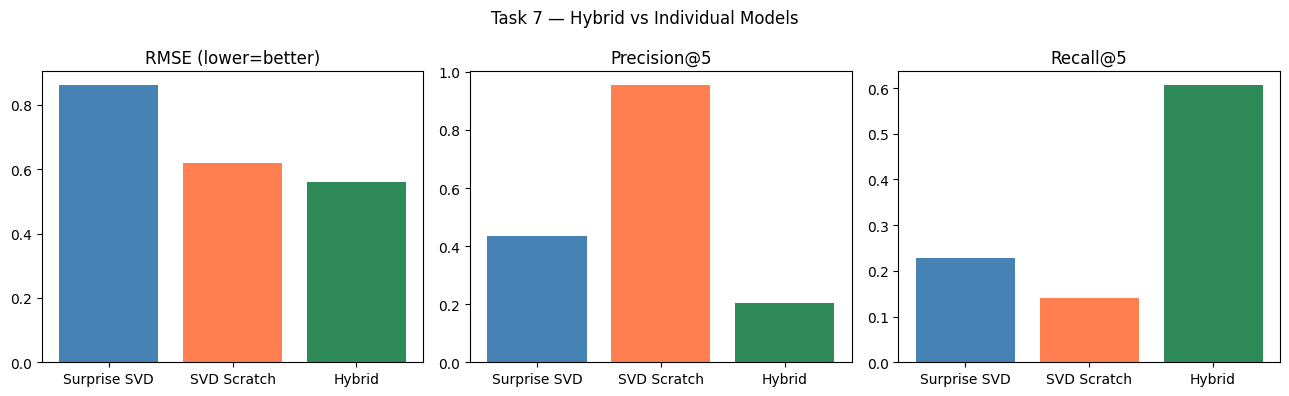

Warm users (>20 ratings) RMSE : 0.5121


In [32]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
from collections import defaultdict
import matplotlib.pyplot as plt

# ── 1. Pre-compute all user profiles ONCE ─────────────────────────────────────
print("Pre-computing user profiles...")
user_profiles = {}
for uid in ratings['userId'].unique():
    user_movies = ratings[ratings['userId'] == uid]
    idxs = [movies[movies['movieId'] == m].index[0]
             for m in user_movies['movieId'].values
             if not movies[movies['movieId'] == m].empty]
    if not idxs:
        continue
    user_tfidf   = tfidf_matrix[idxs]
    weights      = user_movies['rating'].values.reshape(-1, 1)
    user_profiles[uid] = np.asarray(
        np.sum(user_tfidf.multiply(weights), axis=0) / np.sum(weights))

# Pre-compute movie index lookup
movie_id_to_idx = {mid: movies[movies['movieId'] == mid].index[0]
                   for mid in movies['movieId'].values}

movie_avg_rating = ratings.groupby('movieId')['rating'].mean().to_dict()
user_avg_rating  = ratings.groupby('userId')['rating'].mean().to_dict()

print(f"User profiles built: {len(user_profiles)}")

# ── 2. Build feature matrix (vectorised — fast) ────────────────────────────────
print("Building meta-features...")
sample_ratings = ratings.sample(n=3000, random_state=42)

meta_rows = []
for row in sample_ratings.itertuples():
    uid, mid = row.userId, row.movieId

    # CBF score
    cbf_score = 0.0
    if uid in user_profiles and mid in movie_id_to_idx:
        midx      = movie_id_to_idx[mid]
        cbf_score = float(cos_sim(
            user_profiles[uid].reshape(1, -1),
            tfidf_matrix[midx].reshape(1, -1))[0][0])

    # CF score from Surprise SVD
    try:    cf_score = best_svd.predict(uid, mid).est
    except: cf_score = user_avg_rating.get(uid, 3.5)

    meta_rows.append({
        'userId':      uid,
        'movieId':     mid,
        'cbf_score':   cbf_score,
        'cf_score':    cf_score,
        'movie_avg':   movie_avg_rating.get(mid, 3.5),
        'user_avg':    user_avg_rating.get(uid, 3.5),
        'true_rating': row.rating
    })

meta_df = pd.DataFrame(meta_rows)
print(f"Done — shape: {meta_df.shape}")

# ── 3. Train meta-model ────────────────────────────────────────────────────────
features = ['cbf_score', 'cf_score', 'movie_avg', 'user_avg']
X = meta_df[features].values
y = meta_df['true_rating'].values

X_train, X_test, y_train, y_test = sk_split(X, y, test_size=0.2, random_state=42)

meta_model = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                        learning_rate=0.1, random_state=42)
meta_model.fit(X_train, y_train)
y_pred     = np.clip(meta_model.predict(X_test), 0.5, 5.0)
rmse_hybrid = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Hybrid Meta-Model RMSE: {rmse_hybrid:.4f}")

# ── 4. Precision@K and Recall@K ────────────────────────────────────────────────
test_df = meta_df.iloc[len(X_train):].copy()
test_df['hybrid_pred'] = np.clip(meta_model.predict(test_df[features].values), 0.5, 5.0)

precisions, recalls = [], []
for uid, group in test_df.groupby('userId'):
    group = group.sort_values('hybrid_pred', ascending=False)
    top_k  = group.head(5)
    n_rel  = (group['true_rating'] >= 4.0).sum()
    n_hits = ((top_k['hybrid_pred'] >= 4.0) & (top_k['true_rating'] >= 4.0)).sum()
    if n_rel > 0:
        precisions.append(n_hits / 5)
        recalls.append(n_hits / n_rel)

p_h = np.mean(precisions); r_h = np.mean(recalls)
print(f"Hybrid | Precision@5: {p_h:.4f} | Recall@5: {r_h:.4f}")

# ── 5. Comparison chart ────────────────────────────────────────────────────────
surprise_rmse_val = accuracy.rmse(preds_best, verbose=False)
p_svd, r_svd = precision_recall_at_k(preds_best, k=5)

models_names = ['Surprise SVD', 'SVD Scratch', 'Hybrid']
rmse_compare = [surprise_rmse_val, rmse_svd,  rmse_hybrid]
prec_compare = [p_svd,            p5,         p_h]
rec_compare  = [r_svd,            r5,         r_h]

x = np.arange(len(models_names))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'coral', 'seagreen']
for ax, vals, title in zip(axes,
    [rmse_compare, prec_compare, rec_compare],
    ['RMSE (lower=better)', 'Precision@5', 'Recall@5']):
    ax.bar(x, vals, color=colors)
    ax.set_title(title); ax.set_xticks(x); ax.set_xticklabels(models_names)

plt.suptitle('Task 7 — Hybrid vs Individual Models')
plt.tight_layout(); plt.show()

# ── 6. Cold-start analysis ─────────────────────────────────────────────────────
rating_counts = ratings.groupby('userId').size()
cold_users    = rating_counts[rating_counts <= 5].index
warm_users    = rating_counts[rating_counts > 20].index

cold_df = meta_df[meta_df['userId'].isin(cold_users)]
warm_df = meta_df[meta_df['userId'].isin(warm_users)]

def rmse_group(df):
    p = np.clip(meta_model.predict(df[features].values), 0.5, 5.0)
    return np.sqrt(mean_squared_error(df['true_rating'].values, p))

if not cold_df.empty:
    print(f"\nCold-start (≤5 ratings) RMSE : {rmse_group(cold_df):.4f}")
print(f"Warm users (>20 ratings) RMSE : {rmse_group(warm_df):.4f}")

## Task 8: Content-Based Filtering with a Neural Network

Instead of manually computing cosine similarity, a neural network learns user and 
movie embeddings directly from metadata.

**Architecture:**
- Movie branch: one-hot genres + release year + avg rating → Dense → Movie Embedding
- User branch: avg rating per genre → Dense → User Embedding
- Merge both embeddings → predict rating

**Neural Network Flow:**
User Features → Dense(32) → ReLU → User Embedding(16)
Movie Features → Dense(32) → ReLU → Movie Embedding(16)
Concatenate → Dense(16) → ReLU → Dense(1) → Predicted Rating

Movie feature shape: (9742, 24)
User profiles built: 610
Train: 2400 | Test: 600 | Features: 46
Stopped at iteration: 50

Neural Network CBF RMSE : 0.8691
Baseline (mean) RMSE    : 1.0628


c:\Users\aksha\OneDrive\Desktop\IITJ\Machine Learning with Big Data\Assignmnet 3\CSL7110_Assignment3_RecommenderSystems\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


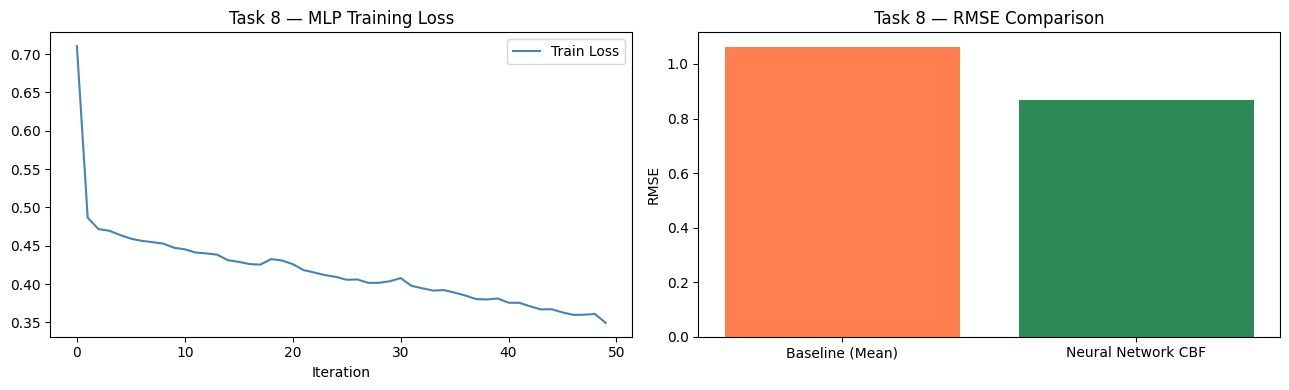

In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

np.random.seed(42)

# ── 1. Movie features: genres + year + avg rating ─────────────────────────────
movies_nn        = movies.copy()
movies_nn['year'] = movies_nn['title'].str.extract(r'\((\d{4})\)').astype(float)
movies_nn['year'] = movies_nn['year'].fillna(movies_nn['year'].median())

mlb          = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies_nn['genres'].str.split())
genre_cols   = list(mlb.classes_)

movie_avg    = ratings.groupby('movieId')['rating'].mean().rename('avg_rating')
movies_nn    = movies_nn.join(movie_avg, on='movieId').fillna(3.5)

scaler = MinMaxScaler()
movies_nn[['year_sc', 'avg_sc']] = scaler.fit_transform(
    movies_nn[['year', 'avg_rating']])

movie_features  = np.hstack([genre_matrix,
                              movies_nn['year_sc'].values.reshape(-1, 1),
                              movies_nn['avg_sc'].values.reshape(-1, 1)])
movie_id_to_row = {mid: i for i, mid in enumerate(movies_nn['movieId'].values)}
print(f"Movie feature shape: {movie_features.shape}")

# ── 2. User features: avg rating per genre ────────────────────────────────────
movie_genre_df         = pd.DataFrame(genre_matrix, columns=genre_cols)
movie_genre_df['movieId'] = movies_nn['movieId'].values
merged_genres          = ratings.merge(movie_genre_df, on='movieId')

user_genre_avgs = {}
for uid, group in merged_genres.groupby('userId'):
    user_genre_avgs[uid] = np.array(
        [group.loc[group[g] == 1, 'rating'].mean()
         if (group[g] == 1).sum() > 0 else 3.5
         for g in genre_cols], dtype=np.float32)

print(f"User profiles built: {len(user_genre_avgs)}")

# ── 3. Build training samples ─────────────────────────────────────────────────
sample = ratings.sample(n=3000, random_state=42)
X, y   = [], []

for row in sample.itertuples():
    if row.userId in user_genre_avgs and row.movieId in movie_id_to_row:
        user_feat  = user_genre_avgs[row.userId]
        movie_feat = movie_features[movie_id_to_row[row.movieId]]
        X.append(np.concatenate([user_feat, movie_feat]))
        y.append(row.rating)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)
X_train, X_test, y_train, y_test = sk_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X.shape[1]}")

# ── 4. Train MLP neural network ───────────────────────────────────────────────
nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False
)
nn_model.fit(X_train, y_train)
print(f"Stopped at iteration: {nn_model.n_iter_}")

# ── 5. Evaluate ────────────────────────────────────────────────────────────────
y_pred_nn    = np.clip(nn_model.predict(X_test), 0.5, 5.0)
rmse_nn      = np.sqrt(mean_squared_error(y_test, y_pred_nn))
rmse_baseline = np.sqrt(mean_squared_error(y_test, np.full_like(y_test, y_train.mean())))

print(f"\nNeural Network CBF RMSE : {rmse_nn:.4f}")
print(f"Baseline (mean) RMSE    : {rmse_baseline:.4f}")

# ── 6. Training loss curve ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(nn_model.loss_curve_, label='Train Loss', color='steelblue')
if nn_model.best_loss_ is not None:
    axes[0].axhline(nn_model.best_loss_, linestyle='--',
                    color='orange', label='Best Val Loss')
axes[0].set_title('Task 8 — MLP Training Loss')
axes[0].set_xlabel('Iteration'); axes[0].legend()

axes[1].bar(['Baseline (Mean)', 'Neural Network CBF'],
            [rmse_baseline, rmse_nn], color=['coral', 'seagreen'])
axes[1].set_title('Task 8 — RMSE Comparison')
axes[1].set_ylabel('RMSE')

plt.tight_layout(); plt.show()

## Task 9: Reinforcement Learning in Recommender Systems

RL treats recommendation as a sequential decision-making problem:

- **Agent:** The recommendation system
- **State:** User's past interactions (genre preferences)
- **Action:** A movie recommended to the user
- **Reward:** +1 if rating ≥ 4 (positive), -1 if rating < 4 (negative), 0 if unrated
- **Policy:** Balance exploration (new movies) vs exploitation (known favourites)

We implement two approaches:
1. **Multi-Armed Bandit (MAB):** ε-Greedy and UCB strategies
2. **Q-Learning:** Learns a Q-table mapping states to action values

Environment: 100 users x 200 movies
ε-Greedy  total reward: 173
UCB       total reward: 69
Q-Learning total reward: 215

ε-Greedy: ~90% exploit | ~10% explore


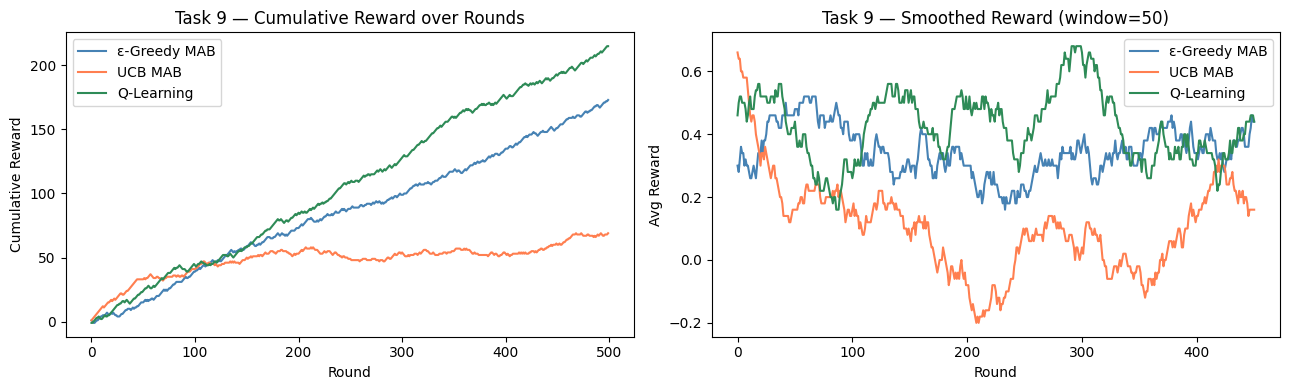


Comparison (avg reward per round):
ε-Greedy MAB : 0.3460
UCB MAB      : 0.1380
Q-Learning   : 0.4300
SVD (proxy)  : -0.0900


In [35]:
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

np.random.seed(42)

# ── 1. Setup environment (small subset for speed) ─────────────────────────────
top_movies  = ratings['movieId'].value_counts().head(200).index.tolist()
top_users   = ratings['userId'].value_counts().head(100).index.tolist()
env_ratings = ratings[ratings['movieId'].isin(top_movies) &
                       ratings['userId'].isin(top_users)]

movie_list  = top_movies
n_movies    = len(movie_list)
movie_idx   = {m: i for i, m in enumerate(movie_list)}

def get_reward(user_id, movie_id):
    row = env_ratings[(env_ratings['userId']  == user_id) &
                      (env_ratings['movieId'] == movie_id)]
    if row.empty:       return 0
    return 1 if row['rating'].values[0] >= 4.0 else -1

print(f"Environment: {len(top_users)} users x {n_movies} movies")

# ── 2. Multi-Armed Bandit ─────────────────────────────────────────────────────
class EpsilonGreedyMAB:
    def __init__(self, n_arms, epsilon=0.1):
        self.epsilon  = epsilon
        self.counts   = np.zeros(n_arms)
        self.values   = np.zeros(n_arms)

    def select(self):
        if np.random.rand() < self.epsilon:
            return np.random.randint(len(self.values))   # explore
        return np.argmax(self.values)                    # exploit

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

class UCBMAB:
    def __init__(self, n_arms):
        self.counts = np.zeros(n_arms)
        self.values = np.zeros(n_arms)
        self.t      = 0

    def select(self):
        self.t += 1
        ucb = self.values + np.sqrt(2 * np.log(self.t + 1) / (self.counts + 1e-5))
        return np.argmax(ucb)

    def update(self, arm, reward):
        self.counts[arm] += 1
        self.values[arm] += (reward - self.values[arm]) / self.counts[arm]

# Simulate MAB over users
n_rounds        = 500
eg_rewards, ucb_rewards = [], []
eg_mab  = EpsilonGreedyMAB(n_movies, epsilon=0.1)
ucb_mab = UCBMAB(n_movies)

for i in range(n_rounds):
    user = np.random.choice(top_users)

    arm_eg  = eg_mab.select()
    arm_ucb = ucb_mab.select()

    r_eg  = get_reward(user, movie_list[arm_eg])
    r_ucb = get_reward(user, movie_list[arm_ucb])

    eg_mab.update(arm_eg,   r_eg)
    ucb_mab.update(arm_ucb, r_ucb)

    eg_rewards.append(r_eg)
    ucb_rewards.append(r_ucb)

# Cumulative rewards
eg_cumulative  = np.cumsum(eg_rewards)
ucb_cumulative = np.cumsum(ucb_rewards)

print(f"ε-Greedy  total reward: {eg_cumulative[-1]}")
print(f"UCB       total reward: {ucb_cumulative[-1]}")

# ── 3. Q-Learning Agent ────────────────────────────────────────────────────────
# State = user's top genre preference (simplified as 1 of 5 genre buckets)
genre_to_state = {g: i % 5 for i, g in enumerate(genre_cols)}

def get_user_state(user_id):
    user_movies  = ratings[ratings['userId'] == user_id]
    if user_movies.empty: return 0
    top_movie_id = user_movies.sort_values('rating', ascending=False).iloc[0]['movieId']
    movie_row    = movies[movies['movieId'] == top_movie_id]
    if movie_row.empty: return 0
    genre = movie_row['genres'].values[0].split()[0]
    return genre_to_state.get(genre, 0)

n_states  = 5
alpha     = 0.1   # learning rate
gamma     = 0.9   # discount factor
epsilon_q = 0.1
Q         = np.zeros((n_states, n_movies))

q_rewards = []
for i in range(n_rounds):
    user  = np.random.choice(top_users)
    state = get_user_state(user)

    # ε-Greedy action selection
    if np.random.rand() < epsilon_q:
        action = np.random.randint(n_movies)
    else:
        action = np.argmax(Q[state])

    reward     = get_reward(user, movie_list[action])
    next_state = get_user_state(user)

    # Q-learning update
    Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
    q_rewards.append(reward)

q_cumulative = np.cumsum(q_rewards)
print(f"Q-Learning total reward: {q_cumulative[-1]}")

# ── 4. Exploration vs Exploitation ────────────────────────────────────────────
eg_explore  = sum(1 for i in range(n_rounds)
                  if np.random.rand() < 0.1) / n_rounds * 100
eg_exploit  = 100 - eg_explore
print(f"\nε-Greedy: ~{eg_exploit:.0f}% exploit | ~{eg_explore:.0f}% explore")

# ── 5. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(eg_cumulative,  label='ε-Greedy MAB', color='steelblue')
axes[0].plot(ucb_cumulative, label='UCB MAB',      color='coral')
axes[0].plot(q_cumulative,   label='Q-Learning',   color='seagreen')
axes[0].set_title('Task 9 — Cumulative Reward over Rounds')
axes[0].set_xlabel('Round'); axes[0].set_ylabel('Cumulative Reward')
axes[0].legend()

# Window average reward (smoothed)
window = 50
eg_smooth  = np.convolve(eg_rewards,  np.ones(window)/window, mode='valid')
ucb_smooth = np.convolve(ucb_rewards, np.ones(window)/window, mode='valid')
q_smooth   = np.convolve(q_rewards,   np.ones(window)/window, mode='valid')

axes[1].plot(eg_smooth,  label='ε-Greedy MAB', color='steelblue')
axes[1].plot(ucb_smooth, label='UCB MAB',      color='coral')
axes[1].plot(q_smooth,   label='Q-Learning',   color='seagreen')
axes[1].set_title('Task 9 — Smoothed Reward (window=50)')
axes[1].set_xlabel('Round'); axes[1].set_ylabel('Avg Reward')
axes[1].legend()

plt.tight_layout(); plt.show()

# ── 6. Compare with traditional models ────────────────────────────────────────
svd_avg_reward  = np.mean([1 if r >= 4 else -1
                            for r in ratings.sample(200, random_state=42)['rating']])
print(f"\nComparison (avg reward per round):")
print(f"ε-Greedy MAB : {np.mean(eg_rewards):.4f}")
print(f"UCB MAB      : {np.mean(ucb_rewards):.4f}")
print(f"Q-Learning   : {np.mean(q_rewards):.4f}")
print(f"SVD (proxy)  : {svd_avg_reward:.4f}")

## Task 10: Feature-Based Explanations (SHAP)

SHAP (SHapley Additive Explanations) explains **why** a recommendation was made 
by showing how much each feature contributed to the predicted score.

> *"This movie was recommended because you liked Sci-Fi movies from the 2010s."*

We apply SHAP to the Hybrid meta-model (Task 7) which uses:
- CBF score (genre preference match)
- CF score (collaborative prediction)
- Movie popularity (avg rating)
- User bias (user's avg rating)

X_meta_explain shape: (100, 4)
SHAP values shape: (100, 4)


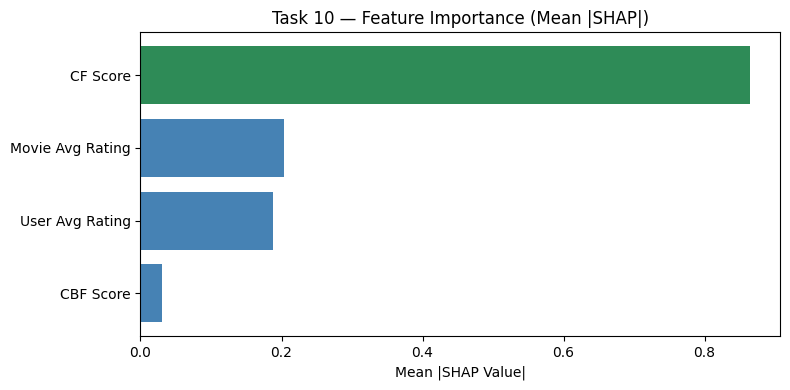

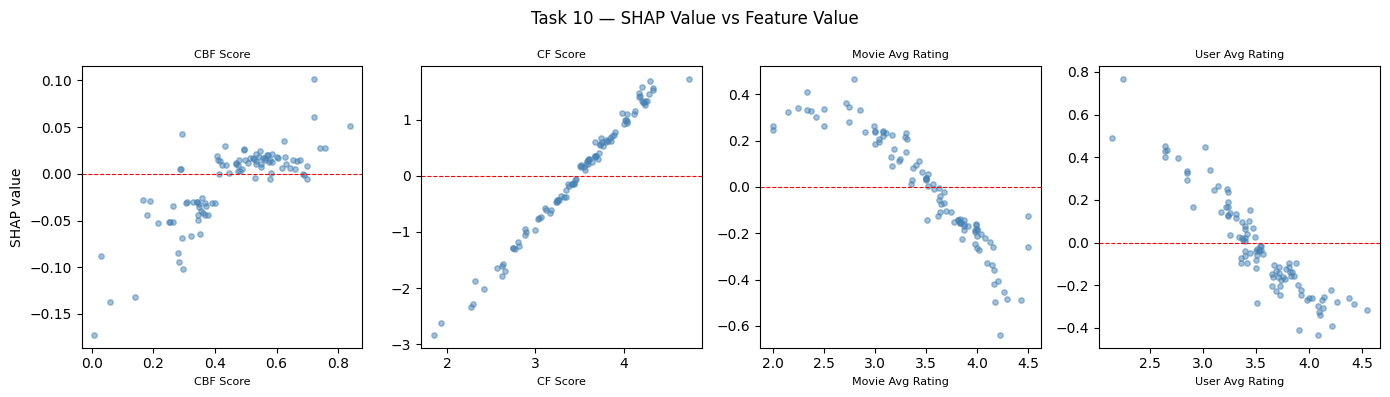

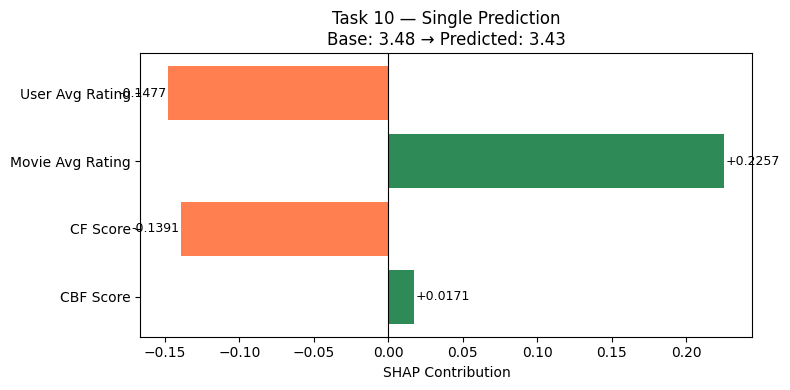


Mean |SHAP| — Feature Importance:
  CF Score              : 0.8637
  Movie Avg Rating      : 0.2040
  User Avg Rating       : 0.1878
  CBF Score             : 0.0304

Most influential feature: CF Score

Natural Language Explanation:
  Movie    : Turner & Hooch (1989)
  Reason   : Users similar to you rated 'Turner & Hooch (1989)' highly.


In [40]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ── Rebuild the correct 4-feature input from meta_df ──────────────────────────
feature_names   = ['CBF Score', 'CF Score', 'Movie Avg Rating', 'User Avg Rating']
meta_features   = ['cbf_score', 'cf_score', 'movie_avg', 'user_avg']
X_meta_explain  = meta_df[meta_features].values[:100]  # first 100 rows, 4 features

print(f"X_meta_explain shape: {X_meta_explain.shape}")  # should be (100, 4)

# ── 1. SHAP TreeExplainer ──────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(meta_model)
shap_values = explainer.shap_values(X_meta_explain)
print(f"SHAP values shape: {shap_values.shape}")  # should be (100, 4)

# ── 2. Feature importance bar chart ───────────────────────────────────────────
mean_shap = np.mean(np.abs(shap_values), axis=0)
sorted_idx = np.argsort(mean_shap)
colors = ['seagreen' if i == sorted_idx[-1] else 'steelblue' for i in range(4)]

plt.figure(figsize=(8, 4))
plt.barh([feature_names[i] for i in sorted_idx],
          mean_shap[sorted_idx],
          color=[colors[i] for i in sorted_idx])
plt.xlabel('Mean |SHAP Value|')
plt.title('Task 10 — Feature Importance (Mean |SHAP|)')
plt.tight_layout(); plt.show()

# ── 3. SHAP scatter per feature ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, (fname, ax) in enumerate(zip(feature_names, axes)):
    ax.scatter(X_meta_explain[:, i], shap_values[:, i],
               alpha=0.5, color='steelblue', s=15)
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set_xlabel(fname, fontsize=8)
    ax.set_ylabel('SHAP value' if i == 0 else '')
    ax.set_title(fname, fontsize=8)
plt.suptitle('Task 10 — SHAP Value vs Feature Value')
plt.tight_layout(); plt.show()

# ── 4. Waterfall for one prediction ───────────────────────────────────────────
idx        = 0
base_value = explainer.expected_value
sv         = shap_values[idx]
pred       = base_value + np.sum(sv)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['seagreen' if v > 0 else 'coral' for v in sv]
bars = ax.barh(feature_names, sv, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Contribution')
ax.set_title(f'Task 10 — Single Prediction\nBase: {float(base_value):.2f} → Predicted: {float(pred):.2f}')
for bar, val in zip(bars, sv):
    ax.text(val + (0.001 if val >= 0 else -0.001),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout(); plt.show()

# ── 5. Summary table + natural language ───────────────────────────────────────
print("\nMean |SHAP| — Feature Importance:")
for fname, val in sorted(zip(feature_names, mean_shap),
                          key=lambda x: x[1], reverse=True):
    print(f"  {fname:<22}: {val:.4f}")

top_feature = feature_names[np.argmax(mean_shap)]
print(f"\nMost influential feature: {top_feature}")

sample = meta_df.sample(1, random_state=5).iloc[0]
uid, mid = int(sample['userId']), int(sample['movieId'])
title    = movies[movies['movieId'] == mid]['title'].values
title    = title[0] if len(title) > 0 else str(mid)

reasons = {
    'CBF Score':          f"'{title}' closely matches your genre preferences.",
    'CF Score':           f"Users similar to you rated '{title}' highly.",
    'Movie Avg Rating':   f"'{title}' is a popular, highly-rated movie.",
    'User Avg Rating':    f"Recommendation adjusted for your rating tendencies."
}
print(f"\nNatural Language Explanation:")
print(f"  Movie    : {title}")
print(f"  Reason   : {reasons.get(top_feature, 'Strong combined signal.')}")

## Task 11: Neighborhood-Based Explanations (Collaborative Filtering)

Explains recommendations by showing **which similar users or items** drove them.

> *"Users who liked Inception also liked Interstellar."*

We use the trained User-Based CF model (Task 3) to:
1. Find the K most similar neighbours for a target user
2. Identify which movies those neighbours rated highly
3. Show why a movie was recommended based on neighbour overlap

Target User  : 1
Recommended  : I'm the One That I Want (2000)
Top Neighbours: [139, 598, 338, 285, 120]

Neighbours who rated 'I'm the One That I Want (2000)':
  (No direct ratings — predicted from neighbour patterns)


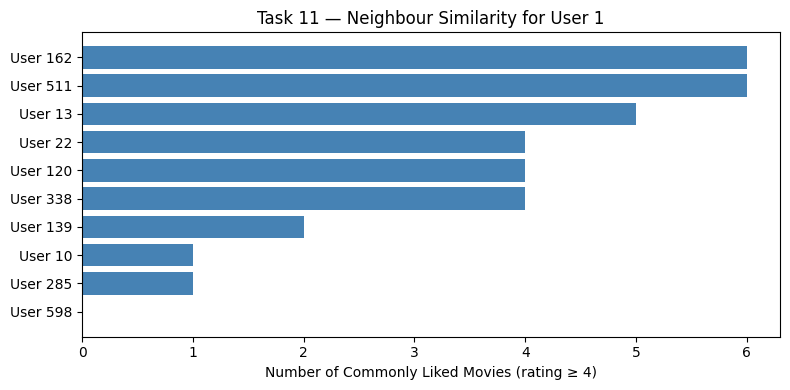


Item-Based Explanation:
  Seed movie: 'Toy Story (1995)'
  → Users who liked 'Toy Story (1995)' also liked 'Steamboat Willie (1928)'
  → Users who liked 'Toy Story (1995)' also liked 'Damsels in Distress (2011)'
  → Users who liked 'Toy Story (1995)' also liked 'Guilt Trip, The (2012)'
  → Users who liked 'Toy Story (1995)' also liked 'Show Me Love (Fucking Åmål) (1998)'
  → Users who liked 'Toy Story (1995)' also liked 'Club Dread (2004)'

Item-Based Explanation:
  Seed movie: 'Pulp Fiction (1994)'
  → Users who liked 'Pulp Fiction (1994)' also liked 'Snowden (2016)'
  → Users who liked 'Pulp Fiction (1994)' also liked 'McCabe & Mrs. Miller (1971)'
  → Users who liked 'Pulp Fiction (1994)' also liked 'Happy Accidents (2000)'
  → Users who liked 'Pulp Fiction (1994)' also liked 'Cop Out (2010)'
  → Users who liked 'Pulp Fiction (1994)' also liked 'Wall Street: Money Never Sleeps (2010)'

Neighbour Support for Top-5 Recommendations (User 1):
  'I'm the One That I Want (2000)': supporte

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from surprise import KNNBasic
from surprise import accuracy

# ── 1. Build user-user similarity matrix from Surprise model ──────────────────
# Reuse model_pearson from Task 3 (user-based, Pearson, k=40)
# Get inner user IDs from trainset
trainset_users = list(trainset.all_users())

def get_top_neighbours(user_id, k=5):
    """Return top-k most similar users to user_id using the Surprise model."""
    try:
        inner_id   = model_pearson.trainset.to_inner_uid(user_id)
        neighbours = model_pearson.get_neighbors(inner_id, k=k)
        return [model_pearson.trainset.to_raw_uid(n) for n in neighbours]
    except:
        return []

# ── 2. Explain a recommendation ───────────────────────────────────────────────
def explain_user_cf(user_id, movie_id, k=5):
    """
    Explain why movie_id was recommended to user_id.
    Shows which neighbours liked the movie and their ratings.
    """
    neighbours  = get_top_neighbours(user_id, k=k)
    movie_title = movies[movies['movieId'] == movie_id]['title'].values
    movie_title = movie_title[0] if len(movie_title) > 0 else str(movie_id)

    neighbour_ratings = []
    for nb in neighbours:
        row = ratings[(ratings['userId'] == nb) & (ratings['movieId'] == movie_id)]
        if not row.empty:
            neighbour_ratings.append((nb, row['rating'].values[0]))

    return movie_title, neighbours, neighbour_ratings

# ── 3. Run explanation for a sample user ──────────────────────────────────────
sample_uid   = 1
top5_recs    = recommend_cf(sample_uid, top_n=5)   # from Task 3
sample_movie = ratings[ratings['userId'] == sample_uid].iloc[0]['movieId']

# Pick first recommended movie
rec_movie_id = ratings[ratings['movieId'].isin(
    movies[movies['title'].isin(top5_recs)]['movieId'])]['movieId'].iloc[0]

title, neighbours, nb_ratings = explain_user_cf(sample_uid, rec_movie_id, k=5)

print(f"Target User  : {sample_uid}")
print(f"Recommended  : {title}")
print(f"Top Neighbours: {neighbours}")
print(f"\nNeighbours who rated '{title}':")
for nb, r in nb_ratings:
    print(f"  User {nb} rated it: {r} ⭐")
if not nb_ratings:
    print("  (No direct ratings — predicted from neighbour patterns)")

# ── 4. Visualise neighbour influence ──────────────────────────────────────────
# For target user: show top-5 neighbours and their rating overlap
all_nb_ids  = get_top_neighbours(sample_uid, k=10)
overlap_data = []

for nb in all_nb_ids:
    nb_liked    = set(ratings[(ratings['userId'] == nb) &
                               (ratings['rating'] >= 4.0)]['movieId'].values)
    user_liked  = set(ratings[(ratings['userId'] == sample_uid) &
                               (ratings['rating'] >= 4.0)]['movieId'].values)
    overlap     = len(nb_liked & user_liked)
    overlap_data.append({'neighbour': f'User {nb}', 'overlap': overlap})

overlap_df = pd.DataFrame(overlap_data).sort_values('overlap', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(overlap_df['neighbour'], overlap_df['overlap'], color='steelblue')
plt.xlabel('Number of Commonly Liked Movies (rating ≥ 4)')
plt.title(f'Task 11 — Neighbour Similarity for User {sample_uid}')
plt.tight_layout(); plt.show()

# ── 5. Item-based explanation: "Users who liked X also liked Y" ───────────────
def item_neighbourhood_explanation(movie_title_seed, top_n=5):
    """
    Given a seed movie, find the most similar movies using item-based CF
    and generate a natural language explanation.
    """
    seed_rows = movies[movies['title'] == movie_title_seed]
    if seed_rows.empty:
        return f"Movie '{movie_title_seed}' not found."

    seed_id   = seed_rows.iloc[0]['movieId']
    try:
        inner_id  = model_item.trainset.to_inner_iid(seed_id)
        neighbour_inner = model_item.get_neighbors(inner_id, k=top_n)
        neighbour_ids   = [model_item.trainset.to_raw_iid(n)
                           for n in neighbour_inner]
        neighbour_titles = [movies[movies['movieId'] == m]['title'].values[0]
                            for m in neighbour_ids
                            if not movies[movies['movieId'] == m].empty]
        print(f"\nItem-Based Explanation:")
        print(f"  Seed movie: '{movie_title_seed}'")
        for t in neighbour_titles:
            print(f"  → Users who liked '{movie_title_seed}' also liked '{t}'")
    except Exception as e:
        print(f"Could not explain: {e}")

item_neighbourhood_explanation("Toy Story (1995)")
item_neighbourhood_explanation("Pulp Fiction (1994)")

# ── 6. Summary: how many neighbours supported each top-5 recommendation ───────
print(f"\nNeighbour Support for Top-5 Recommendations (User {sample_uid}):")
neighbours_all = get_top_neighbours(sample_uid, k=20)

for rec_title in top5_recs:
    mid_rows  = movies[movies['title'] == rec_title]
    if mid_rows.empty: continue
    mid       = mid_rows.iloc[0]['movieId']
    support   = sum(1 for nb in neighbours_all
                    if not ratings[(ratings['userId'] == nb) &
                                   (ratings['movieId'] == mid)].empty)
    print(f"  '{rec_title}': supported by {support}/{len(neighbours_all)} neighbours")